# Setup & Imports

In [2]:
import sys
import numpy as np

# Add the src directory to the Python path
sys.path.append("src")

from QuantumCircuit import QuantumCircuit
from gates.registry import GateRegistry
from error_channels.default_noise import build_default_noise_model
from error_channels.ChannelRegistry import ChannelRegistry
from gates.registry import Gate

### Parse QASM File

In [12]:
import json
from pathlib import Path
from qasm_parser import parse_qasm_file

demo_qasm_path = Path("demo_qasm.qasm")

demo_qasm_source = """
OPENQASM 2.0;
include "qelib1.inc";

qreg q[2];
creg c[2];

h q[0];
cx q[0], q[1];
measure q -> c;
"""

demo_qasm_path.write_text(demo_qasm_source.strip())

print(f"Wrote demo QASM to: {demo_qasm_path.resolve()}")
basis_gates = ["x", "h", "cx", "measure", "reset"]

ir = parse_qasm_file(demo_qasm_path, basis_gates=basis_gates)

print(f"Parsed QASM File:\n{json.dumps(ir, indent=2)}")


Wrote demo QASM to: C:\Users\ik_ad\quantum_circuit_simulator\src\demo_qasm.qasm
Parsed QASM File:
{
  "n_qubits": 2,
  "n_clbits": 2,
  "ops": [
    {
      "name": "h",
      "qargs": [
        0
      ],
      "cargs": [],
      "params": [],
      "condition": null
    },
    {
      "name": "cx",
      "qargs": [
        0,
        1
      ],
      "cargs": [],
      "params": [],
      "condition": null
    },
    {
      "name": "measure",
      "qargs": [
        0
      ],
      "cargs": [
        0
      ],
      "params": [],
      "condition": null
    },
    {
      "name": "measure",
      "qargs": [
        1
      ],
      "cargs": [
        1
      ],
      "params": [],
      "condition": null
    }
  ]
}


# Create Quantum Circuit

In [3]:
# Create a 2-qubit circuit
qc = QuantumCircuit(num_qubits=2, num_cbits=2, enable_metrics=True)

qc


QuantumCircuit(num_qubits=2, num_cbits=2, gates=0)

# Apply Gates (H, X, CNOT)

In [4]:
gate_reg = GateRegistry()
# Access built-in gates through registry
H = gate_reg.get("h")
X = gate_reg.get("x")
CNOT = gate_reg.get("cx")

# Apply gates
qc.add_gate(H, 0)         # Hadamard on qubit 0
qc.add_gate(X, 1)         # X on qubit 1
qc.add_gate(CNOT, [0, 1]) # CNOT: control=0, target=1

qc.ops


[('gate', <gates.registry.Gate at 0x228a21ee340>, 0),
 ('gate', <gates.registry.Gate at 0x228a4338640>, 1),
 ('gate', <gates.registry.Gate at 0x228a43386d0>, [0, 1])]

# Measure Qubits

In [5]:
qc.measure(0, 0)  # measure qubit 0 into classical bit 0
qc.measure(1, 1)  # measure qubit 1 into classical bit 1

qc.ops


[('gate', <gates.registry.Gate at 0x228a21ee340>, 0),
 ('gate', <gates.registry.Gate at 0x228a4338640>, 1),
 ('gate', <gates.registry.Gate at 0x228a43386d0>, [0, 1]),
 ('measure', 0, 0),
 ('measure', 1, 1)]

# Execute the Circuit

In [10]:
result_state = qc.execute(verbose=True)

print("Final state vector:")
print(result_state)

QUANTUM CIRCUIT EXECUTION RESULT

[CIRCUIT INFO]
  Qubits:       2
  Classical:    2
  Operations:   5 (3 gates, 2 measurements, 0 resets)

[CLASSICAL REGISTER]
  Bitstring: |01⟩
  c[0] = 0
  c[1] = 1

[MEASUREMENTS]
  q[0] → 0 (stored in c[0])
  q[1] → 1 (stored in c[1])

[FINAL STATE]
  |01⟩: +1.000000  (P = 1.000000)

[PERFORMANCE METRICS]
  Execution time: 0.004716s
  Peak memory:    91.80 MB
  Memory delta:   +0.00 MB


Final state vector:
{'simulation_type': 'statevector', 'circuit_info': {'num_qubits': 2, 'num_cbits': 2, 'num_operations': 5, 'gate_count': 3, 'measurement_count': 2, 'reset_count': 0}, 'state_vector': array([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j]), 'probabilities': array([0., 1., 0., 0.]), 'classical_bits': {'c[0]': 0, 'c[1]': 1, 'bitstring': '01'}, 'measurements': {'q[0]': {'outcome': 0, 'stored_in': 'c[0]'}, 'q[1]': {'outcome': 1, 'stored_in': 'c[1]'}}, 'metrics': {'execution': {'total_time_seconds': 0.004715899999609974, 'start_time': 5380.3189023, 'end_time': 5380.32

# Measurement Results

In [11]:
print("Measurement results:")
print(qc.get_cbits().get_bits())


Measurement results:
[0 1]


# Error Channels 

Implemented quantum noise channels:
- **Bit Flip Channel**: Flips |0⟩ ↔ |1⟩ with probability p
- **Phase Flip Channel**: Applies phase flip with probability p
- **Depolarizing Channel**: General noise model
- **Custom Kraus Operators**: User-defined error channels

In [9]:
# Initialize channel registry
chan_reg = ChannelRegistry()

print("Available channels:")
print(chan_reg.list())

# Demonstrate Bit Flip Channel
print("\n" + "="*60)
print("BIT FLIP CHANNEL")
print("="*60)
bit_flip_30 = chan_reg.get_param('bit_flip').instantiate(0.3)
print(f"{bit_flip_30}")
print(f"Number of Kraus operators: {len(bit_flip_30.kraus_ops)}")

# Apply bit flip to |0⟩ state multiple times to see stochastic behavior
print("\nApplying bit flip (p=0.3) to |0⟩ state:")
psi_0 = np.array([1.0, 0.0], dtype=complex)
for i in range(5):
    result = bit_flip_30.apply_statevector(psi_0.copy())
    print(f"Trial {i+1}: {result} -> measured as |{np.argmax(np.abs(result))}⟩")

Available channels:
['amplitude_damping', 'bit_flip', 'bit_phase_flip', 'depolarizing', 'phase_damping', 'phase_flip']

BIT FLIP CHANNEL
bit_flip (1q) Channel with 2 Kraus ops
Number of Kraus operators: 2

Applying bit flip (p=0.3) to |0⟩ state:
Trial 1: [1.+0.j 0.+0.j] -> measured as |0⟩
Trial 2: [0.+0.j 1.+0.j] -> measured as |1⟩
Trial 3: [1.+0.j 0.+0.j] -> measured as |0⟩
Trial 4: [1.+0.j 0.+0.j] -> measured as |0⟩
Trial 5: [0.+0.j 1.+0.j] -> measured as |1⟩


# Pauli Simulator

## Import necessary Libraries

In [ ]:
from pauli_simulator.batch_tableau import BatchTableau
from pauli_simulator.Tableau_Ver2 import Tableau

## Tableau Creation

In [70]:
def hadamard_single_qubit_demo(shots, enable_metrics=True):
    outcomes = []

    for _ in range(shots):
        # 1 qubit, no classical bits needed for this demo
        t = Tableau(n=2, num_cbits=0, enable_metrics=enable_metrics)
        t.h(0)
        m = t.measure(0)
        outcomes.append(m)

    outcomes = np.array(outcomes)
    p0 = np.mean(outcomes == 0)
    p1 = np.mean(outcomes == 1)

    print(f"Shots: {shots}")
    print(f"P(0) ≈ {p0:.3f}, P(1) ≈ {p1:.3f}")


hadamard_single_qubit_demo(shots=1000)


Shots: 1000
P(0) ≈ 0.496, P(1) ≈ 0.504


In [73]:
from collections import Counter

def bell_state_demo(shots=1000):
    counts = Counter()

    for _ in range(shots):
        t = Tableau(n=2, num_cbits=0, enable_metrics=False)
        t.h(0)
        t.cx(0, 1)
        m0 = t.measure(0)
        m1 = t.measure(1)
        bitstring = f"{m0}{m1}"  # order: q0 q1
        counts[bitstring] += 1

    print("Counts:", counts)

    # Sort keys for plotting
    keys = ["00", "01", "10", "11"]
    vals = [counts.get(k, 0) for k in keys]


    # Also print empirical probabilities
    total = sum(counts.values())
    for k in keys:
        print(f"P({k}) ≈ {counts.get(k, 0)/total:.3f}")

bell_state_demo(shots=2000)



Counts: Counter({'11': 1027, '00': 973})
P(00) ≈ 0.486
P(01) ≈ 0.000
P(10) ≈ 0.000
P(11) ≈ 0.513


## Random Clifford Circuit and Metrics

In [ ]:
def random_clifford_circuit(n_qubits, depth, seed=0):
    rng = np.random.default_rng(seed)
    t = Tableau(n=n_qubits, num_cbits=0, enable_metrics=True)

    single_qubit_gates = ["h", "s", "x", "y", "z"]

    for _ in range(depth):
        gate_type = rng.choice(["single", "cx", "measure"], p=[0.6, 0.3, 0.1])

        if gate_type == "single":
            q = int(rng.integers(0, n_qubits))
            g = rng.choice(single_qubit_gates)
            if g == "h":
                t.h(q)
            elif g == "s":
                t.s(q)
            elif g == "x":
                t.x(q)
            elif g == "y":
                t.y(q)
            elif g == "z":
                t.z(q)

        elif gate_type == "cx":
            c = int(rng.integers(0, n_qubits))
            t_q = int(rng.integers(0, n_qubits))
            if c != t_q:
                t.cx(c, t_q)

        elif gate_type == "measure":
            q = int(rng.integers(0, n_qubits))
            t.measure(q)

    return t

t_rand = random_clifford_circuit(n_qubits=2, depth=100, seed=42)
t_rand.print_circuit()

metrics = t_rand.get_metrics()
t_rand.print_metrics()

metrics  



TABLEAU CIRCUIT: 2 qubits, 0 classical bits

Operations (86 total):

    1. CX   q[1], q[0]
    2. CX   q[0], q[1]
    3. Z    q[1]
    4. X    q[1]
    5. Z    q[0]
    6. CX   q[0], q[1]
    7. S    q[0]
    8. H    q[1]
    9. CX   q[0], q[1]
   10. CX   q[1], q[0]
   11. MEAS q[0] (outcome: 0)
   12. X    q[0]
   13. Y    q[0]
   14. CX   q[1], q[0]
   15. Z    q[1]
   16. Y    q[0]
   17. Y    q[0]
   18. X    q[0]
   19. H    q[1]
   20. CX   q[1], q[0]
   21. Z    q[1]
   22. CX   q[0], q[1]
   23. Z    q[0]
   24. CX   q[0], q[1]
   25. CX   q[1], q[0]
   26. X    q[1]
   27. S    q[1]
   28. CX   q[0], q[1]
   29. H    q[0]
   30. Y    q[1]
   31. S    q[0]
   32. S    q[0]
   33. Z    q[0]
   34. X    q[0]
   35. X    q[1]
   36. CX   q[1], q[0]
   37. H    q[0]
   38. CX   q[0], q[1]
   39. Z    q[0]
   40. X    q[1]
   41. H    q[1]
   42. Y    q[0]
   43. Z    q[1]
   44. S    q[0]
   45. MEAS q[1] (outcome: 1)
   46. MEAS q[0] (outcome: 0)
   47. H    q[0]
   48. MEAS q[

{'execution': {'total_time_seconds': 0.0027336000639479607,
  'start_time': None,
  'end_time': None},
 'operations': {'gate_count': 77,
  'measurement_count': 9,
  'total_operations': 86,
  'gates_by_type': {'h': 13, 's': 10, 'cx': 18, 'x': 14, 'y': 9, 'z': 13}},
 'timing': {'gate_time_seconds': 0.0010541000519879162,
  'measurement_time_seconds': 0.0016795000119600445},
 'measurements': {'deterministic': 4,
  'probabilistic': 5,
  'outcomes': {0: 3, 1: 6}},
 'memory': {'initial_mb': 167.73046875,
  'peak_mb': 167.73046875,
  'final_mb': 167.73046875,
  'delta_mb': 0.0,
  'gate_memory': {'samples': [167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,
    167.73046875,


# Noisy Clifford Simulator Demo

- Builds a Bell state under Pauli noise
- Compares measurement statistics for **low noise** vs **high noise**
- Shows how often noise flips the outcomes


### Helper Function

In [91]:
from pauli_simulator.pauli_error_channels import NoisySimulator, build_default_pauli_error_config

def run_noisy_bell_experiment(
    shots=1000,
    p_1q=0.001,
    p_2q=0.01,
    p_meas=0.002,
):
    """
    Prepare a Bell state with noisy gates and sample measurement outcomes.

    Circuit:
        |00> --H--●--
                 |  |
        |00> ----X--

    We measure both qubits in Z and record bitstrings "00", "01", "10", "11".
    """
    error_config = build_default_pauli_error_config(
        p_1q=p_1q,
        p_2q=p_2q,
        p_meas=p_meas,
    )

    counts = Counter()

    for _ in range(shots):
        sim = NoisySimulator(n=2, error_config=error_config, enable_metrics=False)

        # Ideal Bell state (before noise):
        # H on qubit 0, then CX(0 -> 1)
        sim.h(0)
        sim.cx(0, 1)

        # Noisy measurement: noise is applied inside sim.measure(...)
        m0 = sim.measure(0)
        m1 = sim.measure(1)

        bitstring = f"{m0}{m1}"  # q0 q1
        counts[bitstring] += 1

    # Convert to arrays for plotting
    keys = ["00", "01", "10", "11"]
    vals = np.array([counts.get(k, 0) for k in keys])
    probs = vals / vals.sum()

    # Print and plot
    print(f"shots = {shots}")
    for k, v, p in zip(keys, vals, probs):
        print(f"{k}: {v:5d}  (p ≈ {p:.3f})")

    plt.bar(keys, vals)
    plt.xlabel("Measurement outcome (q0 q1)")
    plt.ylabel("Counts")
    plt.title("Noisy Bell-state measurement statistics")
    plt.show()

    return counts, probs



### Low noise vs High noise

=== Low-noise configuration ===
shots = 2000
00:   995  (p ≈ 0.497)
01:    11  (p ≈ 0.005)
10:    20  (p ≈ 0.010)
11:   974  (p ≈ 0.487)


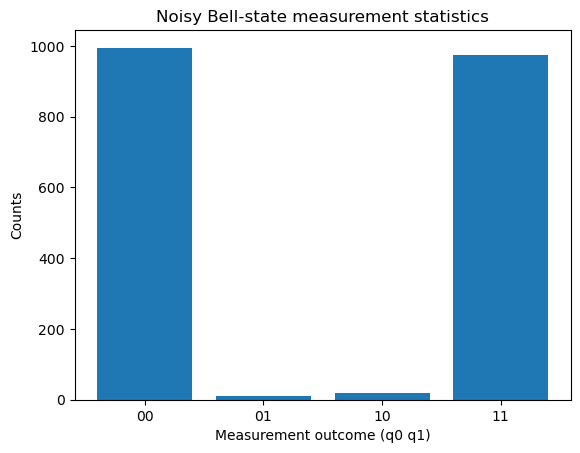


=== High-noise configuration ===
shots = 2000
00:   851  (p ≈ 0.425)
01:   172  (p ≈ 0.086)
10:   186  (p ≈ 0.093)
11:   791  (p ≈ 0.396)


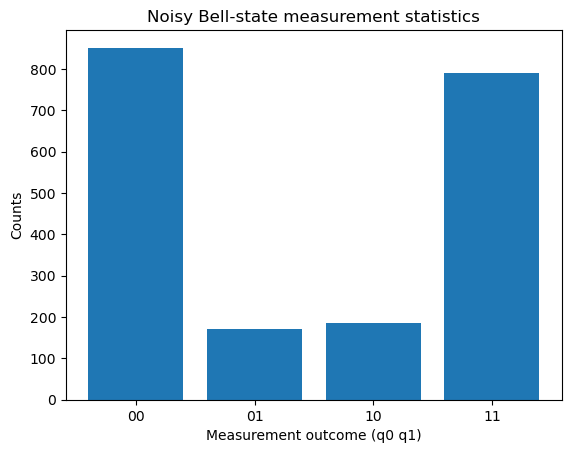

In [92]:
print("=== Low-noise configuration ===")
low_counts, low_probs = run_noisy_bell_experiment(
    shots=2000,
    p_1q=0.001,
    p_2q=0.01,
    p_meas=0.002,
)

print("\n=== High-noise configuration ===")
high_counts, high_probs = run_noisy_bell_experiment(
    shots=2000,
    p_1q=0.05,   # crank up 1-qubit error rate
    p_2q=0.10,   # crank up 2-qubit error rate
    p_meas=0.05, # noisy readout
)
